In [1]:
pip install pymysql sqlalchemy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install openpyxl


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


 # Amazon E-Commerce Analysis

In [4]:
import os
print(os.listdir(r"D:\data analyst project"))


['amazon sales analysis', 'EDA project python', 'New folder', 'retailer data set']


In [5]:
import os
print(os.listdir(r"D:\data analyst project\amazon sales analysis"))


['Amazon Sales.xlsx', '~$Amazon Sales.xlsx']


In [6]:

df = pd.read_excel(r"D:\data analyst project\amazon sales analysis\Amazon Sales.xlsx")
df.head(5)
#sku means stock keeping unit a alpha numeric code assigned to a each product

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,Mumbai,Maharashtra,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,Bengaluru,Karnataka,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,Navi Mumbai,Maharashtra,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,Puducherry,Puducherry,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,Chennai,Tamil Nadu,600073.0,IN,NaN,False,NaN,NaN


In [7]:
df.columns

Index(['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ',
       'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN',
       'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'B2B', 'fulfilled-by', 'Unnamed: 22'],
      dtype='str')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   index               128975 non-null  int64         
 1   Order ID            128975 non-null  str           
 2   Date                128975 non-null  datetime64[us]
 3   Status              128975 non-null  str           
 4   Fulfilment          128975 non-null  str           
 5   Sales Channel       128975 non-null  str           
 6   ship-service-level  128975 non-null  str           
 7   Style               128975 non-null  str           
 8   SKU                 128975 non-null  str           
 9   Category            128975 non-null  str           
 10  Size                128975 non-null  str           
 11  ASIN                128975 non-null  str           
 12  Courier Status      122103 non-null  str           
 13  Qty                 128975 non-null  int

In [9]:
df.shape

(128975, 24)

In [10]:
df.isnull().sum()

index                     0
Order ID                  0
Date                      0
Status                    0
Fulfilment                0
Sales Channel             0
ship-service-level        0
Style                     0
SKU                       0
Category                  0
Size                      0
ASIN                      0
Courier Status         6872
Qty                       0
currency               7795
Amount                 7795
ship-city                33
ship-state               33
ship-postal-code         33
ship-country             33
promotion-ids         49153
B2B                       0
fulfilled-by          89698
Unnamed: 22           49050
dtype: int64

In [11]:
df.isnull().sum()/len(df)*100

index                  0.000000
Order ID               0.000000
Date                   0.000000
Status                 0.000000
Fulfilment             0.000000
Sales Channel          0.000000
ship-service-level     0.000000
Style                  0.000000
SKU                    0.000000
Category               0.000000
Size                   0.000000
ASIN                   0.000000
Courier Status         5.328164
Qty                    0.000000
currency               6.043807
Amount                 6.043807
ship-city              0.025586
ship-state             0.025586
ship-postal-code       0.025586
ship-country           0.025586
promotion-ids         38.110487
B2B                    0.000000
fulfilled-by          69.546811
Unnamed: 22           38.030626
dtype: float64

In [12]:
df.describe()

,index,Date,Qty,Amount,ship-postal-code,Unnamed: 22
count,128975.000000,128975,128975.000000,121180.000000,128942.000000,79925.0
mean,64487.000000,2022-05-12 11:49:27.951929,0.904431,648.561465,463966.236509,0.0
min,0.000000,2022-03-31 00:00:00,0.000000,0.000000,110001.000000,0.0
25%,32243.500000,2022-04-20 00:00:00,1.000000,449.000000,382421.000000,0.0
50%,64487.000000,2022-05-10 00:00:00,1.000000,605.000000,500033.000000,0.0
75%,96730.500000,2022-06-04 00:00:00,1.000000,788.000000,600024.000000,0.0
max,128974.000000,2022-06-29 00:00:00,15.000000,5584.000000,989898.000000,0.0
std,37232.019822,NaN,0.313354,281.211687,191476.764941,0.0


In [13]:
# Checking duplicates
df[df.duplicated()].shape

(0, 24)

In [14]:
df.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
128970    False
128971    False
128972    False
128973    False
128974    False
Length: 128975, dtype: bool

In [15]:
#there is no rwows are duplicated
df[df.duplicated()]

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22


In [16]:
df['Order ID'].value_counts().head(10)

Order ID
403-4984515-8861958    12
171-5057375-2831560    12
403-0173977-3041148    11
404-9932919-6662730    11
408-3317403-1729937    10
406-9002076-4152331     9
171-0706521-2133101     9
171-4310662-2005103     9
404-3701762-8241125     9
408-2964501-8373155     9
Name: count, dtype: int64

In [17]:
#there is no duplicates 
df[df['Order ID'] == '403-4984515-8861958']

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
31737,31737,403-4984515-8861958,2022-04-11,Shipped,Amazon,Amazon.in,Expedited,JNE3792,JNE3792-KR-XXXL,kurta,...,INR,432.0,Solapur,Maharashtra,413002.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
31738,31738,403-4984515-8861958,2022-04-11,Shipped,Amazon,Amazon.in,Expedited,JNE3764,JNE3764-KR-XXXL,kurta,...,INR,487.0,Solapur,Maharashtra,413002.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
31739,31739,403-4984515-8861958,2022-04-11,Shipped,Amazon,Amazon.in,Expedited,JNE3503,JNE3503-KR-XXXL,kurta,...,INR,318.0,Solapur,Maharashtra,413002.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
31740,31740,403-4984515-8861958,2022-04-11,Shipped,Amazon,Amazon.in,Expedited,J0308,J0308-DR-XXXL,Western Dress,...,INR,665.0,Solapur,Maharashtra,413002.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
31741,31741,403-4984515-8861958,2022-04-11,Shipped,Amazon,Amazon.in,Expedited,JNE3702,JNE3702-KR-XXXL,kurta,...,INR,342.0,Solapur,Maharashtra,413002.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
31742,31742,403-4984515-8861958,2022-04-11,Shipped,Amazon,Amazon.in,Expedited,JNE3741,JNE3741-KR-XXXL,kurta,...,INR,432.0,Solapur,Maharashtra,413002.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
31743,31743,403-4984515-8861958,2022-04-11,Shipped,Amazon,Amazon.in,Expedited,JNE3634,JNE3634-KR-XXXL,kurta,...,INR,511.0,Solapur,Maharashtra,413002.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
31744,31744,403-4984515-8861958,2022-04-11,Shipped,Amazon,Amazon.in,Expedited,SET433,SET433-KR-NP-XXXL,Set,...,INR,666.0,Solapur,Maharashtra,413002.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
31745,31745,403-4984515-8861958,2022-04-11,Shipped,Amazon,Amazon.in,Expedited,JNE3636,JNE3636-KR-XXXL,kurta,...,INR,459.0,Solapur,Maharashtra,413002.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
31746,31746,403-4984515-8861958,2022-04-11,Shipped,Amazon,Amazon.in,Expedited,JNE3633,JNE3633-KR-XXXL,kurta,...,INR,459.0,Solapur,Maharashtra,413002.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN


In [18]:
df.columns

Index(['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ',
       'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN',
       'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'B2B', 'fulfilled-by', 'Unnamed: 22'],
      dtype='str')

In [19]:
df['Unnamed: 22'].notna()

0         False
1         False
2         False
3         False
4         False
          ...  
128970     True
128971     True
128972     True
128973     True
128974     True
Name: Unnamed: 22, Length: 128975, dtype: bool

In [20]:
df = df.drop('Unnamed: 22', axis=1)

In [21]:
df.columns

Index(['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ',
       'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN',
       'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'B2B', 'fulfilled-by'],
      dtype='str')

In [22]:
df['Date'] = pd.to_datetime(df['Date']).dt.date

In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 23 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  str    
 2   Date                128975 non-null  object 
 3   Status              128975 non-null  str    
 4   Fulfilment          128975 non-null  str    
 5   Sales Channel       128975 non-null  str    
 6   ship-service-level  128975 non-null  str    
 7   Style               128975 non-null  str    
 8   SKU                 128975 non-null  str    
 9   Category            128975 non-null  str    
 10  Size                128975 non-null  str    
 11  ASIN                128975 non-null  str    
 12  Courier Status      122103 non-null  str    
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  str    
 15  Amount              121180 non-null  float64


In [24]:
df['month'] = pd.to_datetime(df['Date']).dt.strftime('%B')

In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  str    
 2   Date                128975 non-null  object 
 3   Status              128975 non-null  str    
 4   Fulfilment          128975 non-null  str    
 5   Sales Channel       128975 non-null  str    
 6   ship-service-level  128975 non-null  str    
 7   Style               128975 non-null  str    
 8   SKU                 128975 non-null  str    
 9   Category            128975 non-null  str    
 10  Size                128975 non-null  str    
 11  ASIN                128975 non-null  str    
 12  Courier Status      122103 non-null  str    
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  str    
 15  Amount              121180 non-null  float64


In [26]:
df.head(5)

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,month
0,0,405-8078784-5731545,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,Mumbai,Maharashtra,400081.0,IN,NaN,False,Easy Ship,April
1,1,171-9198151-1101146,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,Bengaluru,Karnataka,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,April
2,2,404-0687676-7273146,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,Navi Mumbai,Maharashtra,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,April
3,3,403-9615377-8133951,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,Puducherry,Puducherry,605008.0,IN,NaN,False,Easy Ship,April
4,4,407-1069790-7240320,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,Chennai,Tamil Nadu,600073.0,IN,NaN,False,NaN,April


In [27]:
df[df['Amount']==0].shape

(2343, 24)

In [28]:
df['Amount'].isna().sum()

np.int64(7795)

In [29]:
#most of the amount is blanks for cancelled
df[df['Amount'].isna()]['Status'].value_counts()

Status
Cancelled                       7566
Shipped                          208
Shipped - Delivered to Buyer       8
Shipping                           8
Shipped - Returned to Seller       3
Pending                            2
Name: count, dtype: int64

In [30]:
df.columns

Index(['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ',
       'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN',
       'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'B2B', 'fulfilled-by', 'month'],
      dtype='str')

In [31]:
df[df['Amount'].isna()][['Order ID','Status', 'Fulfilment','promotion-ids', 'Courier Status','Amount','Qty']].value_counts(dropna = False)

Order ID             Status     Fulfilment  promotion-ids                                 Courier Status  Amount  Qty
402-1377777-6716303  Cancelled  Amazon      NaN                                           Cancelled       NaN     0      8
403-7715142-5829168  Cancelled  Amazon      NaN                                           Cancelled       NaN     0      7
407-9261873-2421156  Shipped    Amazon      IN Core Free Shipping 2015/04/08 23-48-5-108  Cancelled       NaN     0      6
405-4895219-2513111  Cancelled  Amazon      NaN                                           Cancelled       NaN     0      6
171-6514723-6694747  Cancelled  Merchant    NaN                                           NaN             NaN     0      5
                                                                                                                        ..
404-3986097-9369916  Cancelled  Amazon      NaN                                           Cancelled       NaN     0      1
406-4220789-1106743  

In [32]:
df[df['Amount'].isna()][['Order ID','Status', 'Fulfilment','promotion-ids', 'Courier Status','Amount','Qty']].head(10)

,Order ID,Status,Fulfilment,promotion-ids,Courier Status,Amount,Qty
8,407-5443024-5233168,Cancelled,Amazon,IN Core Free Shipping 2015/04/08 23-48-5-108,Cancelled,NaN,0
29,404-5933402-8801952,Cancelled,Merchant,NaN,NaN,NaN,0
65,171-4137548-0481151,Cancelled,Amazon,NaN,Cancelled,NaN,0
84,403-9950518-0349133,Cancelled,Amazon,NaN,Cancelled,NaN,0
95,405-9112089-3379536,Cancelled,Amazon,NaN,Cancelled,NaN,0
101,402-7841951-1872363,Cancelled,Amazon,NaN,Cancelled,NaN,0
132,171-0293372-4913973,Cancelled,Amazon,NaN,Cancelled,NaN,0
139,403-6442534-2769112,Cancelled,Amazon,NaN,Cancelled,NaN,0
155,402-8078642-8565124,Cancelled,Amazon,NaN,Cancelled,NaN,0
165,406-0218328-1773963,Cancelled,Amazon,IN Core Free Shipping 2015/04/08 23-48-5-108,Cancelled,NaN,0


In [33]:
print(df.columns.tolist())


['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ', 'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN', 'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city', 'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids', 'B2B', 'fulfilled-by', 'month']


In [34]:
df[df['Amount']==0]['Courier Status'].value_counts()

Courier Status
Shipped      2317
Unshipped      26
Name: count, dtype: int64

In [35]:
df[df['Amount']==0]['Status'].value_counts()

Status
Shipped                          1518
Shipped - Delivered to Buyer      716
Shipped - Returned to Seller       51
Shipped - Picked Up                28
Pending                            17
Pending - Waiting for Pick Up       9
Shipped - Lost in Transit           2
Shipped - Returning to Seller       2
Name: count, dtype: int64

In [36]:
df[df['Amount']==0]['promotion-ids'].value_counts()

promotion-ids
Amazon PLCC Free-Financing Universal Merchant AAT-XXRCW6NZEPZI4,Amazon PLCC Free-Financing Universal Merchant AAT-XX7G3ZRJJJ5LG,Amazon PLCC Free-Financing Universal Merchant AAT-LEHCKNDBJG64E,Amazon PLCC Free-Financing Universal Merchant AAT-DJVHCEV7D7RQY,Amazon PLCC Free-Financing Universal Merchant #MP-gzasho-1593152694811                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    59
Amazon PLCC Free-Financing Universal Merchant AAT-5QQ7BIYYQEDN2,Amazon PLCC F

### Amount Missing Value Analysis

After analysing the Amount column, I found two different situations:

1. Amount = 0
   - There are 2,343 rows where Amount is 0 and Qty = 1.
   - Amount = 0 occurs across multiple order statuses and scenarios.
   - Therefore, 0 cannot be treated as a missing value and should not be replaced.

2. Amount = Blank (NaN)
   - There are 7,795 rows where Amount is blank.
   - 7,671 of these rows have Qty = 0.
   - 124 rows have Qty > 0.
   - Therefore, blank Amount values cannot be filled blindly because there is no single rule that explains all missing values.

3.After inverstigate  124  rows qty >0  
  -  There are 124 rows amountis blank because there courier status in  Unshipped.

Therefore, the blank Amount values cannot be reliably filled because there is no actual Amount value available from which we can derive the missing amount.

Decision:
Keep these Amount values as NaN instead of filling them with 0, mean, median, or any guessed value.

In [37]:
df[df['Amount']==0]['Order ID'].value_counts()

Order ID
408-4547464-4180323    1
408-5020509-5674715    1
408-3137526-3167563    1
408-7971979-8745937    1
408-0912805-7526753    1
                      ..
408-6490796-0249925    1
408-9074023-7691550    1
408-9473849-4953122    1
408-9579839-6574765    1
408-4237588-2626757    1
Name: count, Length: 2343, dtype: int64

In [38]:
df[df['Amount']==0]['Qty'].value_counts()

Qty
1    2343
Name: count, dtype: int64

In [39]:
df[df['Amount'].isna()]['Qty'].value_counts()

Qty
0     7671
1      115
2        4
15       1
9        1
13       1
4        1
3        1
Name: count, dtype: int64

In [41]:
df[df['Amount'].isna() & (df['Qty']>0)][['Order ID','Status', 'Fulfilment','promotion-ids', 'Courier Status','Qty']]

,Order ID,Status,Fulfilment,promotion-ids,Courier Status,Qty
937,S02-5278980-4327051,Shipped,Amazon,NaN,Unshipped,15
1057,S02-9107114-0460608,Shipped,Amazon,NaN,Unshipped,2
3631,S02-1006261-5356758,Shipped,Amazon,NaN,Unshipped,9
3632,S02-3681731-6111841,Shipped,Amazon,NaN,Unshipped,1
3634,S02-1926028-4838217,Shipped,Amazon,NaN,Unshipped,1
...,...,...,...,...,...,...
118099,S02-9176732-4357939,Shipped,Amazon,NaN,Unshipped,1
124616,S02-2059602-9568060,Shipped,Amazon,NaN,Unshipped,1
124617,S02-3811761-8377519,Shipped,Amazon,NaN,Unshipped,2
124619,S02-5216693-3162561,Shipped,Amazon,NaN,Unshipped,1


In [42]:
df[df['Amount'].isna() & (df['Qty']>0)]['Status'].value_counts()

Status
Shipped      115
Shipping       8
Cancelled      1
Name: count, dtype: int64

In [43]:
df[df['Amount'].isna() & (df['Qty']>0)]['Courier Status'].value_counts()

Courier Status
Unshipped    124
Name: count, dtype: int64

### Courier Status Missing Value Analysis

There are 6,872 missing values in Courier Status.

After investigation:
- 6,861 records have Status = Cancelled.
- 8 records have Status = Shipped - Delivered to Buyer.
- 3 records have Status = Shipped - Returned to Seller.

The 11 exception records also have Qty = 0 and Amount = blank.

Since there is no single reliable value that can be assigned to the missing Courier Status values, the missing values will be retained as NaN rather than being artificially filled.

In [44]:
df[df['Courier Status'].isna()][
    ['Order ID', 'Status', 'Fulfilment', 'promotion-ids',
     'Amount', 'Qty','Courier Status']
]

,Order ID,Status,Fulfilment,promotion-ids,Amount,Qty,Courier Status
0,405-8078784-5731545,Cancelled,Merchant,NaN,647.62,0,NaN
3,403-9615377-8133951,Cancelled,Merchant,NaN,753.33,0,NaN
23,404-6019946-2909948,Cancelled,Merchant,NaN,570.48,0,NaN
29,404-5933402-8801952,Cancelled,Merchant,NaN,NaN,0,NaN
83,404-6522553-9345930,Cancelled,Merchant,NaN,1105.36,0,NaN
...,...,...,...,...,...,...,...
128762,402-4651401-6366769,Cancelled,Merchant,NaN,385.71,0,NaN
128808,408-4182027-2307535,Cancelled,Merchant,NaN,NaN,0,NaN
128855,402-1958677-2521967,Cancelled,Merchant,NaN,NaN,0,NaN
128875,403-9524128-9243508,Cancelled,Merchant,NaN,734.29,0,NaN


In [45]:
df[df['Courier Status'].isna()]['Status'].value_counts()
#courier sttaus is blank where  sttaus is cancelled 

Status
Cancelled                       6861
Shipped - Delivered to Buyer       8
Shipped - Returned to Seller       3
Name: count, dtype: int64

In [46]:
df[
    (df['Courier Status'].isna() )&  (df['Status']== 'Shipped - Delivered to Buyer')][['Order ID', 'Status', 'Fulfilment', 'promotion-ids',
     'Amount', 'Qty','Courier Status']]

#courier status is blank because amount is blank

,Order ID,Status,Fulfilment,promotion-ids,Amount,Qty,Courier Status
18894,408-2656493-8935504,Shipped - Delivered to Buyer,Merchant,NaN,NaN,0,NaN
19292,408-0017934-6791513,Shipped - Delivered to Buyer,Merchant,NaN,NaN,0,NaN
23873,407-5638769-8389162,Shipped - Delivered to Buyer,Merchant,NaN,NaN,0,NaN
35337,407-9335911-1673924,Shipped - Delivered to Buyer,Merchant,NaN,NaN,0,NaN
46852,406-5666781-2979508,Shipped - Delivered to Buyer,Merchant,NaN,NaN,0,NaN
63344,404-3955601-0129966,Shipped - Delivered to Buyer,Merchant,NaN,NaN,0,NaN
65174,407-1289751-6335501,Shipped - Delivered to Buyer,Merchant,NaN,NaN,0,NaN
75251,408-7380700-0029922,Shipped - Delivered to Buyer,Merchant,NaN,NaN,0,NaN


In [47]:
df[
    (df['Courier Status'].isna())  & (df['Status'] == 'Shipped - Returned to Seller')
][['Order ID', 'Status', 'Fulfilment', 'promotion-ids',
     'Amount', 'Qty','Courier Status']]
#same with   courier status is blank   because amount is blank

,Order ID,Status,Fulfilment,promotion-ids,Amount,Qty,Courier Status
71443,171-2697577-5967501,Shipped - Returned to Seller,Merchant,NaN,NaN,0,NaN
74296,171-0040661-6643541,Shipped - Returned to Seller,Merchant,NaN,NaN,0,NaN
84211,171-3459992-9664354,Shipped - Returned to Seller,Merchant,NaN,NaN,0,NaN


In [48]:
# Insvestigate promotion id

promotion _ids also analyse but missing value  occur  different fulfillment types, status , Qty  etc, So there is no reliable  rule was found to infer promotion ids

In [49]:
df[df['promotion-ids'].isna()][['Order ID', 'Status', 'Fulfilment', 'promotion-ids',
     'Amount', 'Qty','Courier Status']]

,Order ID,Status,Fulfilment,promotion-ids,Amount,Qty,Courier Status
0,405-8078784-5731545,Cancelled,Merchant,NaN,647.62,0,NaN
3,403-9615377-8133951,Cancelled,Merchant,NaN,753.33,0,NaN
4,407-1069790-7240320,Shipped,Amazon,NaN,574.00,1,Shipped
9,402-4393761-0311520,Shipped,Amazon,NaN,363.00,1,Shipped
10,407-5633625-6970741,Shipped,Amazon,NaN,685.00,1,Shipped
...,...,...,...,...,...,...,...
128966,406-9812666-2474761,Shipped,Amazon,NaN,1132.00,1,Shipped
128967,404-5182288-1653947,Cancelled,Amazon,NaN,NaN,0,Cancelled
128969,404-3802633-7250760,Cancelled,Amazon,NaN,612.00,1,Unshipped
128970,406-6001380-7673107,Shipped,Amazon,NaN,517.00,1,Shipped


In [50]:
df[df['promotion-ids'].isna()]['Fulfilment'].value_counts()

Fulfilment
Amazon      42224
Merchant     6929
Name: count, dtype: int64

In [51]:
df[df['promotion-ids'].isna()]['Qty'].value_counts()

Qty
1     36617
0     12467
2        61
4         2
3         2
15        1
9         1
13        1
8         1
Name: count, dtype: int64

In [52]:
df[
    (df['promotion-ids'].isna())  & (df['Fulfilment']== 'Merchant')
][['Order ID', 'Status', 'Fulfilment', 'promotion-ids',
     'Amount', 'Qty','Courier Status']]

,Order ID,Status,Fulfilment,promotion-ids,Amount,Qty,Courier Status
0,405-8078784-5731545,Cancelled,Merchant,NaN,647.62,0,NaN
3,403-9615377-8133951,Cancelled,Merchant,NaN,753.33,0,NaN
23,404-6019946-2909948,Cancelled,Merchant,NaN,570.48,0,NaN
29,404-5933402-8801952,Cancelled,Merchant,NaN,NaN,0,NaN
83,404-6522553-9345930,Cancelled,Merchant,NaN,1105.36,0,NaN
...,...,...,...,...,...,...,...
128762,402-4651401-6366769,Cancelled,Merchant,NaN,385.71,0,NaN
128808,408-4182027-2307535,Cancelled,Merchant,NaN,NaN,0,NaN
128855,402-1958677-2521967,Cancelled,Merchant,NaN,NaN,0,NaN
128875,403-9524128-9243508,Cancelled,Merchant,NaN,734.29,0,NaN


In [53]:
df[
    (df['promotion-ids'].isna()) & (df['Qty'] >0)
]

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,month
4,4,407-1069790-7240320,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.0,Chennai,Tamil Nadu,600073.0,IN,NaN,False,NaN,April
9,9,402-4393761-0311520,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3461,JNE3461-KR-XXL,kurta,...,INR,363.0,Chennai,Tamil Nadu,600041.0,IN,NaN,False,NaN,April
10,10,407-5633625-6970741,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3160,JNE3160-KR-G-S,kurta,...,INR,685.0,Chennai,Tamil Nadu,600073.0,IN,NaN,False,NaN,April
11,11,171-4638481-6326716,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3500,JNE3500-KR-XS,kurta,...,INR,364.0,Noida,Uttar Pradesh,201303.0,IN,NaN,False,NaN,April
13,13,408-7955685-3083534,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,SET182,SET182-KR-DH-XS,Set,...,INR,657.0,Mumbai,Maharashtra,400053.0,IN,NaN,False,NaN,April
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128965,128965,408-5154281-4593912,2022-05-31,Cancelled,Amazon,Amazon.in,Expedited,J0119,J0119-TP-XXXL,Top,...,INR,574.0,Prayagraj (Allahabad),Uttar Pradesh,211007.0,IN,NaN,False,NaN,May
128966,128966,406-9812666-2474761,2022-05-31,Shipped,Amazon,Amazon.in,Expedited,SET224,SET224-KR-NP-XS,Set,...,INR,1132.0,Chennai 600042,Tamil Nadu,600042.0,IN,NaN,False,NaN,May
128969,128969,404-3802633-7250760,2022-05-31,Cancelled,Amazon,Amazon.in,Expedited,SET044,SET044-KR-NP-M,Set,...,INR,612.0,Mumbai,Maharashtra,400017.0,IN,NaN,False,NaN,May
128970,128970,406-6001380-7673107,2022-05-31,Shipped,Amazon,Amazon.in,Expedited,JNE3697,JNE3697-KR-XL,kurta,...,INR,517.0,Hyderabad,Telangana,500013.0,IN,NaN,False,NaN,May


In [54]:
df.columns

Index(['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ',
       'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN',
       'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'B2B', 'fulfilled-by', 'month'],
      dtype='str')

In [55]:
df[df['fulfilled-by'].isna()][['Order ID', 'Status',  'promotion-ids',
     'Amount', 'Qty','Courier Status','fulfilled-by']]

,Order ID,Status,promotion-ids,Amount,Qty,Courier Status,fulfilled-by
2,404-0687676-7273146,Shipped,IN Core Free Shipping 2015/04/08 23-48-5-108,329.0,1,Shipped,NaN
4,407-1069790-7240320,Shipped,NaN,574.0,1,Shipped,NaN
5,404-1490984-4578765,Shipped,IN Core Free Shipping 2015/04/08 23-48-5-108,824.0,1,Shipped,NaN
6,408-5748499-6859555,Shipped,IN Core Free Shipping 2015/04/08 23-48-5-108,653.0,1,Shipped,NaN
8,407-5443024-5233168,Cancelled,IN Core Free Shipping 2015/04/08 23-48-5-108,NaN,0,Cancelled,NaN
...,...,...,...,...,...,...,...
128970,406-6001380-7673107,Shipped,NaN,517.0,1,Shipped,NaN
128971,402-9551604-7544318,Shipped,IN Core Free Shipping 2015/04/08 23-48-5-108,999.0,1,Shipped,NaN
128972,407-9547469-3152358,Shipped,NaN,690.0,1,Shipped,NaN
128973,402-6184140-0545956,Shipped,IN Core Free Shipping 2015/04/08 23-48-5-108,1199.0,1,Shipped,NaN


##fulfilment   by also analyse but missing value  occur  different fulfillment types, status , Qty  etc, So there is no reliable
rule was found to infer  fulfilment by 

In [56]:
df[df['fulfilled-by'].isna()]['Courier Status'].value_counts(dropna=False)

Courier Status
Shipped      77606
Unshipped     6157
Cancelled     5935
Name: count, dtype: int64

In [57]:
df[df['fulfilled-by'].isna()]['Status'].value_counts(dropna=False)

Status
Shipped      77804
Cancelled    11471
Pending        415
Shipping         8
Name: count, dtype: int64

In [58]:
print(df.columns.tolist())

['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ', 'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN', 'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city', 'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids', 'B2B', 'fulfilled-by', 'month']


The 33 records have missing values in all four shipping-location columns (ship-city, ship-state, ship-postal-code, ship-country). These records occur across different courier statuses, including shipped, unshipped, cancelled, and records where Courier Status itself is missing. 
    Therefore, no reliable pattern was found to reconstruct the missing shipping information. The missing values are retained as NaN.

In [59]:
df[df[['ship-city','ship-state', 'ship-postal-code', 'ship-country' ]].isna().any(axis =1)][['Order ID',
    'Status',
    'Fulfilment',
    'fulfilled-by',
    'Courier Status',
    'Amount',
    'Qty',
    'promotion-ids',
    'ship-city',
    'ship-state',
    'ship-postal-code',
    'ship-country']]

,Order ID,Status,Fulfilment,fulfilled-by,Courier Status,Amount,Qty,promotion-ids,ship-city,ship-state,ship-postal-code,ship-country
1871,404-0566904-4825137,Shipped,Amazon,NaN,Shipped,493.0,1,IN Core Free Shipping 2015/04/08 23-48-5-108,NaN,NaN,NaN,NaN
1872,404-0566904-4825137,Shipped,Amazon,NaN,Shipped,458.0,1,IN Core Free Shipping 2015/04/08 23-48-5-108,NaN,NaN,NaN,NaN
8752,406-4003386-8768363,Shipped,Amazon,NaN,Shipped,432.0,1,NaN,NaN,NaN,NaN,NaN
11215,402-0107720-7057168,Shipped,Amazon,NaN,Shipped,654.0,1,IN Core Free Shipping 2015/04/08 23-48-5-108,NaN,NaN,NaN,NaN
13252,407-4532637-8415521,Cancelled,Merchant,Easy Ship,NaN,380.0,0,NaN,NaN,NaN,NaN,NaN
15688,404-9229894-8608305,Shipped,Amazon,NaN,Shipped,442.0,1,IN Core Free Shipping 2015/04/08 23-48-5-108,NaN,NaN,NaN,NaN
16787,402-4919636-4333150,Shipped - Delivered to Buyer,Merchant,Easy Ship,Shipped,376.0,1,Amazon PLCC Free-Financing Universal Merchant ...,NaN,NaN,NaN,NaN
18351,405-4927647-8064368,Shipped,Amazon,NaN,Shipped,1112.0,1,IN Core Free Shipping 2015/04/08 23-48-5-108,NaN,NaN,NaN,NaN
22930,402-8628677-0457954,Shipped - Returned to Seller,Merchant,Easy Ship,Shipped,654.0,1,Amazon PLCC Free-Financing Universal Merchant ...,NaN,NaN,NaN,NaN
24986,406-4079063-8291520,Cancelled,Amazon,NaN,Unshipped,399.0,1,NaN,NaN,NaN,NaN,NaN


In [60]:
df[df[['ship-city','ship-state', 'ship-postal-code', 'ship-country' ]].isna().any(axis =1)]['Qty'].value_counts()

Qty
1    28
0     5
Name: count, dtype: int64

In [61]:
df[df[['ship-city','ship-state', 'ship-postal-code', 'ship-country' ]].isna().any(axis =1)]['Courier Status'].value_counts(dropna = False)

Courier Status
Shipped      26
NaN           3
Unshipped     2
Cancelled     2
Name: count, dtype: int64

In [62]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  str    
 2   Date                128975 non-null  object 
 3   Status              128975 non-null  str    
 4   Fulfilment          128975 non-null  str    
 5   Sales Channel       128975 non-null  str    
 6   ship-service-level  128975 non-null  str    
 7   Style               128975 non-null  str    
 8   SKU                 128975 non-null  str    
 9   Category            128975 non-null  str    
 10  Size                128975 non-null  str    
 11  ASIN                128975 non-null  str    
 12  Courier Status      122103 non-null  str    
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  str    
 15  Amount              121180 non-null  float64


In [63]:
df['ship-postal-code'] = df['ship-postal-code'].astype('Int64')

In [64]:
print(df.columns.tolist())

['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ', 'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN', 'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city', 'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids', 'B2B', 'fulfilled-by', 'month']


In [65]:
df.duplicated().sum()

np.int64(0)

In [66]:
df[df.duplicated()]

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,month


In [67]:
df[df.duplicated(keep=False)]


,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,month


In [68]:
df_clean = df.drop_duplicates()

In [69]:
df.duplicated().sum()

np.int64(0)

In [70]:
df[df.duplicated(keep = False)]

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,month


In [71]:
df[df.duplicated(keep=False)].shape

(0, 24)

In [72]:
df = df.drop_duplicates()

In [73]:
print(df.shape)
print(df.duplicated().sum())

(128975, 24)
0


In [141]:
categorical_cols = [ 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ', 'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN', 'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city', 'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids', 'B2B', 'fulfilled-by', 'month']
for col  in categorical_cols:
    print(f"\n---------------------------------{col}-------------------------")
    print(df[col].value_counts(dropna = False)) 


---------------------------------Order ID-------------------------
Order ID
403-4984515-8861958    12
171-5057375-2831560    12
403-0173977-3041148    11
404-9932919-6662730    11
408-3317403-1729937    10
                       ..
406-6001380-7673107     1
402-9551604-7544318     1
407-9547469-3152358     1
402-6184140-0545956     1
408-7436540-8728312     1
Name: count, Length: 120378, dtype: int64

---------------------------------Date-------------------------
Date
2022-05-03    2085
2022-05-02    2079
2022-05-04    2015
2022-04-14    1883
2022-04-15    1853
              ... 
2022-06-23    1090
2022-06-24    1028
2022-06-25    1026
2022-06-29     658
2022-03-31     171
Name: count, Length: 91, dtype: int64

---------------------------------Status-------------------------
Status
Shipped                          77804
Shipped - Delivered to Buyer     28769
Cancelled                        18332
Shipped - Returned to Seller      1953
Shipped - Picked Up                973
Pending    

In [143]:
state_mapping = {
     'Rajshthan': 'Rajasthan',
     'Rajsthan' : 'Rajasthan',  
    'Rj': 'Rajasthan',
    'Orissa': 'Odisha',
    'Pb': 'Punjab',
    'Pondicherry': 'Puducherry'
}
    
df['ship-state'] = df['ship-state'].replace(state_mapping)

In [144]:
state_mapping = {
    'Nl' : 'Nagaland',
    'Ar' : 'Arunachal Pradesh',
    'Punjab/Mohali/Zirakpur' : 'Punjab'    
    
}
df['ship-state'] = df['ship-state'].replace(state_mapping)

In [77]:
df['ship-state'].value_counts()

ship-state
Maharashtra          22260
Karnataka            17326
Tamil Nadu           11483
Telangana            11330
Uttar Pradesh        10638
Delhi                 6967
Kerala                6585
West Bengal           5963
Andhra Pradesh        5430
Gujarat               4489
Haryana               4415
Rajasthan             2718
Madhya Pradesh        2529
Odisha                2139
Bihar                 2114
Punjab                1919
Assam                 1663
Uttarakhand           1553
Jharkhand             1456
Goa                   1137
Chhattisgarh           909
Himachal Pradesh       788
Jammu & Kashmir        702
Puducherry             351
Chandigarh             333
Manipur                316
Andaman & Nicobar      257
Meghalaya              207
Sikkim                 205
Nagaland               187
Tripura                151
Arunachal Pradesh      147
New Delhi               81
Mizoram                 76
Dadra And Nagar         70
Ladakh                  43
Lakshadweep      

In [78]:
df[['Qty', 'Amount']].describe()

,Qty,Amount
count,128975.000000,121180.000000
mean,0.904431,648.561465
std,0.313354,281.211687
min,0.000000,0.000000
25%,1.000000,449.000000
50%,1.000000,605.000000
75%,1.000000,788.000000
max,15.000000,5584.000000


In [79]:
print("Qty = 0 is:",( df['Qty']==0).sum())
print("Qty > 0 is:",(df['Qty']>0).sum())
print("Qty < 0 is:", (df['Qty'] < 0).sum())

Qty = 0 is: 12807
Qty > 0 is: 116168
Qty < 0 is: 0


In [80]:
print("Amount = 0 is:",( df['Amount']==0).sum())
print("Amount > 0 is:",(df['Amount']<0).sum())

Amount = 0 is: 2343
Amount > 0 is: 0


In [81]:
print("Maximum Date",df['Date'].max())
print("Minimum Date",df['Date'].min())
print("Missing Date",df['Date'].isna().sum())

Maximum Date 2022-06-29
Minimum Date 2022-03-31
Missing Date 0


#Exploratory Data Analysis

Overall Business performance

In [82]:
print(df.columns.tolist())

['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ', 'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN', 'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city', 'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids', 'B2B', 'fulfilled-by', 'month']


In [83]:
Total_Orders = df['Order ID'].nunique()
Total_Orders

120378

In [84]:
Total_Sales = df['Amount'].sum()
Total_Sales

np.float64(78592678.3)

In [85]:
Total_Quantity = df['Qty'].sum()
Total_Quantity

np.int64(116649)

In [86]:
Average_Order_Value = Total_Sales/Total_Orders
Average_Order_Value

np.float64(652.8824062536344)

In [87]:
print("Total Sales =", round(Total_Sales, 2))
print("Average Order Value =", round(Average_Order_Value, 2))

Total Sales = 78592678.3
Average Order Value = 652.88


In [88]:
df.columns

Index(['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ',
       'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN',
       'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'B2B', 'fulfilled-by', 'month'],
      dtype='str')

## 1. Order Status Analysis

In [89]:
df['Status'].value_counts()

Status
Shipped                          77804
Shipped - Delivered to Buyer     28769
Cancelled                        18332
Shipped - Returned to Seller      1953
Shipped - Picked Up                973
Pending                            658
Pending - Waiting for Pick Up      281
Shipped - Returning to Seller      145
Shipped - Out for Delivery          35
Shipped - Rejected by Buyer         11
Shipping                             8
Shipped - Lost in Transit            5
Shipped - Damaged                    1
Name: count, dtype: int64

In [90]:
status_order = df.groupby('Status')['Order ID'].nunique().sort_values(ascending = False)
status_order

Status
Shipped                          72826
Shipped - Delivered to Buyer     26566
Cancelled                        17185
Shipped - Returned to Seller      1851
Shipped - Picked Up                918
Pending                            584
Pending - Waiting for Pick Up      262
Shipped - Returning to Seller      130
Shipped - Out for Delivery          32
Shipped - Rejected by Buyer         11
Shipping                             8
Shipped - Lost in Transit            4
Shipped - Damaged                    1
Name: Order ID, dtype: int64

In [91]:
cancelled_orders = df.loc[df['Status'] == 'Cancelled','Order ID'].nunique()

Cancellation_rate = cancelled_orders/Total_Orders *100
print("Cancelled_orders =",cancelled_orders)
print("Cancellation_rate =",  round(Cancellation_rate,2),"%")


Cancelled_orders = 17185
Cancellation_rate = 14.28 %


In [92]:
Shipped_Orders = df.loc[df['Status']=='Shipped','Order ID'].nunique()
Shipped_Orders
Shipped_Orders_rate = Shipped_Orders/Total_Orders *100
print('Shipped_Orders = ', Shipped_Orders)
print("Shipped_Orders_rate = " , round(Shipped_Orders_rate,2) , "%")

Shipped_Orders =  72826
Shipped_Orders_rate =  60.5 %


In [93]:
Shipped_Delivered_to_Buyer_Orders = df.loc[df['Status'] == 'Shipped - Delivered to Buyer', 'Order ID'].nunique()
Shipped_Delivered_to_Buyer_Orders_rate = Shipped_Delivered_to_Buyer_Orders / Total_Orders *100
print('Shipped_Delivered_to_Buyer_Orders = ', Shipped_Delivered_to_Buyer_Orders)
print("Shipped_Delivered_to_Buyer_Orders_rate = " , round(Shipped_Delivered_to_Buyer_Orders,2) ,"%")

Shipped_Delivered_to_Buyer_Orders =  26566
Shipped_Delivered_to_Buyer_Orders_rate =  26566 %


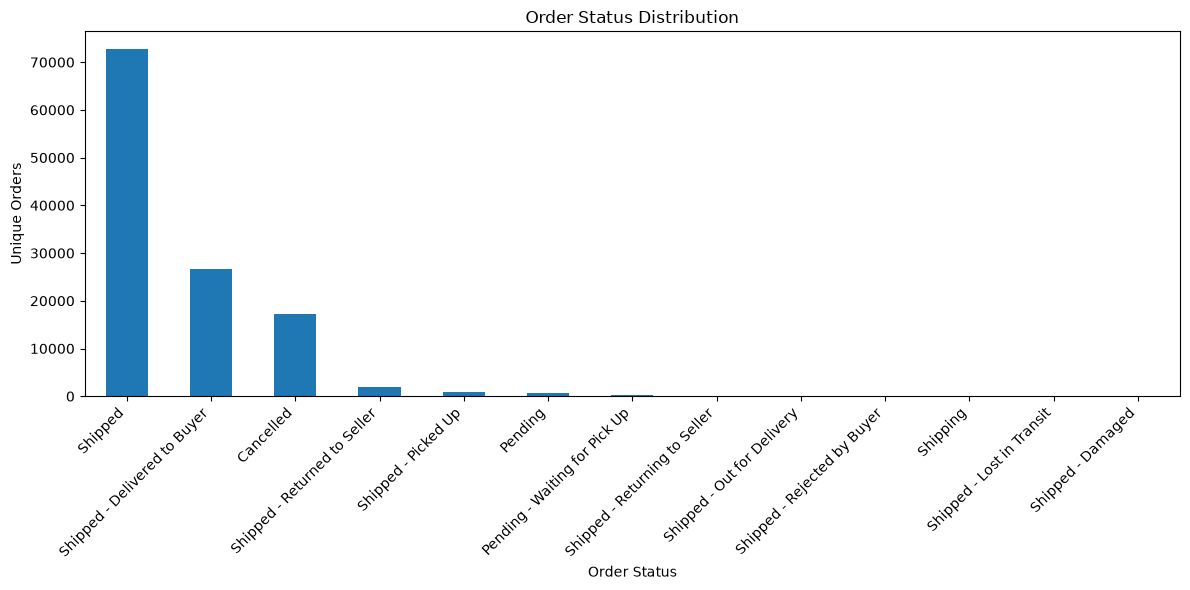

In [94]:
status_orders = df.groupby('Status')['Order ID'].nunique().sort_values(ascending=False)
status_orders.plot(kind='bar', figsize=(12,6))

plt.title('Order Status Distribution')
plt.xlabel('Order Status')
plt.ylabel('Unique Orders')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

"From the above graph we can see that Shipped status has highest numbers of unique orders follow up by shipped_Delivered to Buyer ,
while several other status occurs at much lower frequencies"

In [95]:
status_percentage = ((status_orders / Total_Orders) * 100).sort_values(ascending=False)
print(status_percentage.round(2) )


Status
Shipped                          60.50
Shipped - Delivered to Buyer     22.07
Cancelled                        14.28
Shipped - Returned to Seller      1.54
Shipped - Picked Up               0.76
Pending                           0.49
Pending - Waiting for Pick Up     0.22
Shipped - Returning to Seller     0.11
Shipped - Out for Delivery        0.03
Shipped - Rejected by Buyer       0.01
Shipping                          0.01
Shipped - Lost in Transit         0.00
Shipped - Damaged                 0.00
Name: Order ID, dtype: float64


## 2. Courier-Status Analysis

In [96]:
print(df.columns.tolist())

['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ', 'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN', 'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city', 'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids', 'B2B', 'fulfilled-by', 'month']


In [97]:
df['Courier Status'].value_counts()

Courier Status
Shipped      109487
Unshipped      6681
Cancelled      5935
Name: count, dtype: int64

In [98]:
Courier_Status_Orders = df.groupby('Courier Status')['Order ID'].nunique().sort_values(ascending = False)
Courier_Status_Orders


Courier Status
Shipped      102232
Unshipped      6195
Cancelled      5665
Name: Order ID, dtype: int64

In [99]:
Shipped_Orders = df.loc[df['Courier Status'] == 'Shipped', 'Order ID'].nunique()
Shipped_Orders_rate = Shipped_Orders/ Total_Orders*100
print("Shipped_Orders = ", Shipped_Orders)
print("Shipped_Orders_rate = " , round(Shipped_Orders_rate,2),"%")

Shipped_Orders =  102232
Shipped_Orders_rate =  84.93 %


In [100]:
Unshipped_Orders = df.loc[df['Courier Status'] == 'Unshipped', 'Order ID'].nunique()
Unshipped_Orders_rate = Unshipped_Orders/ Total_Orders*100
print("Unshipped_Orders = ", Unshipped_Orders)
print("Unshipped_Orders_rate = " , round(Unshipped_Orders_rate,2),"%")

Unshipped_Orders =  6195
Unshipped_Orders_rate =  5.15 %


In [101]:
Cancelled_Orders = df.loc[df['Courier Status']== 'Cancelled', 'Order ID'].nunique()
Cancelled_Orders_rate =  Cancelled_Orders/Total_Orders*100 
print('Cancelled_Orders =', Cancelled_Orders)
print('Cancelled_Orders_rate = ', round(Cancelled_Orders_rate,2),"%")

Cancelled_Orders = 5665
Cancelled_Orders_rate =  4.71 %


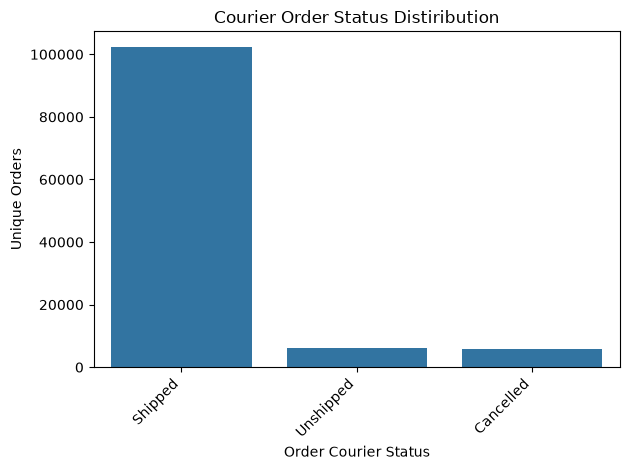

In [102]:
Courier_Status_Orders = df.groupby('Courier Status')['Order ID'].nunique().sort_values(ascending = False)
sns.barplot(x =Courier_Status_Orders.index , y = Courier_Status_Orders.values )
plt.title("Courier Order Status Distiribution")
plt.xlabel('Order Courier Status')
plt.ylabel('Unique Orders')
plt.xticks(rotation = 45 , ha = 'right')
plt.tight_layout()
plt.show()

"From the above graph we can see that Shipped Courier status has highest numbers of unique orders followe up  by Unshipped , 
while sevreral other status occurs at much lower frequencies"

In [103]:
Courier_percentage = (Courier_Status_Orders/Total_Orders)*100
print(Courier_percentage.round(2))

Courier Status
Shipped      84.93
Unshipped     5.15
Cancelled     4.71
Name: Order ID, dtype: float64


## 3. Time Analysis

In [150]:
df['month'].value_counts()

month
April    49067
May      42040
June     37697
March      171
Name: count, dtype: int64

In [153]:
month_order = ['March', 'April', 'May', 'June']
monthly_orders = df.groupby('month')['Order ID'].nunique().reindex(month_order).sort_values(ascending = False)
monthly_sales = df.groupby('month')['Amount'].sum().reindex(month_order).sort_values(ascending = False)
print(monthly_sales)
monthly_Qty = df.groupby('month')['Qty'].sum().reindex(month_order).sort_values(ascending = False)
print(monthly_sales)
print(monthly_Qty)

month
April    28838708.32
May      26226476.75
June     23425809.38
March      101683.85
Name: Amount, dtype: float64
month
April    28838708.32
May      26226476.75
June     23425809.38
March      101683.85
Name: Amount, dtype: float64
month
April    44206
May      38011
June     34276
March      156
Name: Qty, dtype: int64


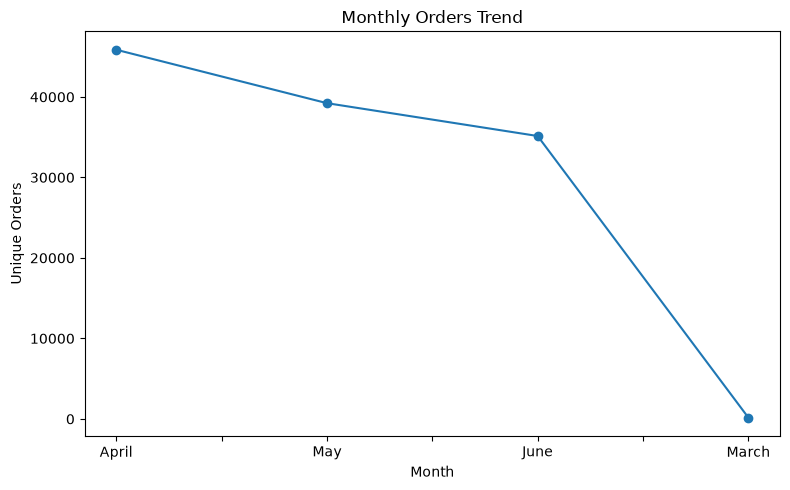

In [154]:
monthly_orders.plot(kind = 'line', marker = 'o',figsize=(8,5))
plt.title('Monthly Orders Trend')
plt.xlabel('Month')
plt.ylabel('Unique Orders')
plt.tight_layout()
plt.show()

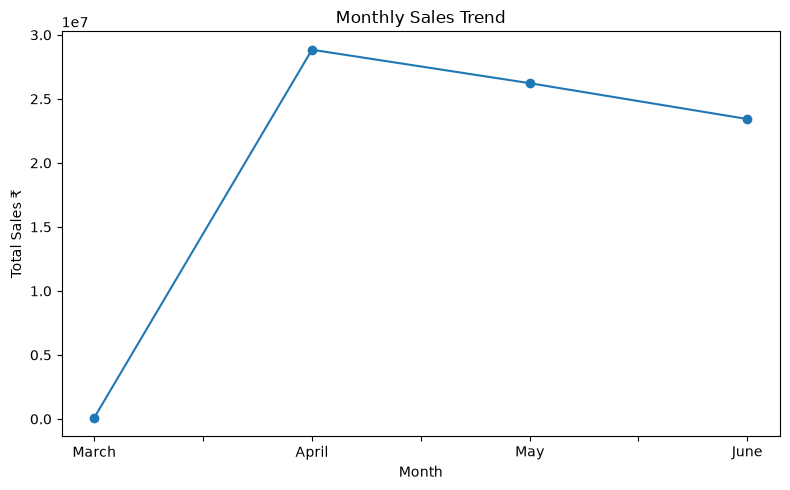

In [107]:
monthly_sales.plot(kind = 'line', marker= 'o' , figsize=(8,5))
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales ₹')
plt.tight_layout()
plt.show()

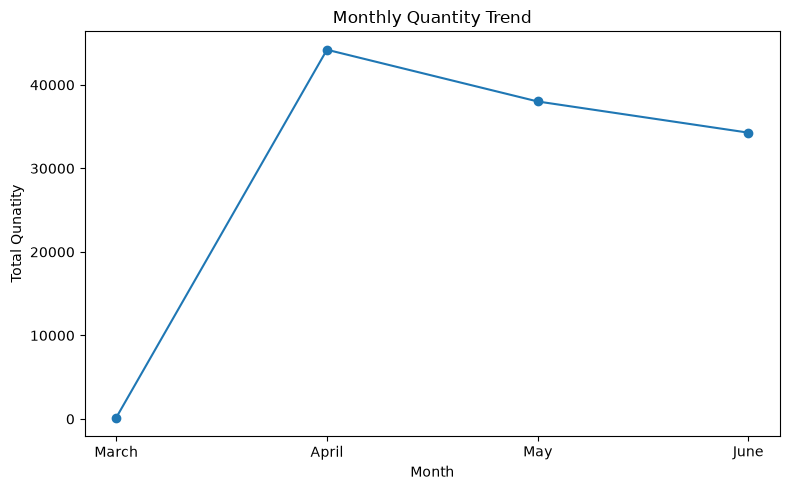

In [108]:
plt.figure(figsize=(8,5))
plt.plot(monthly_Qty.index,monthly_Qty.values, marker = 'o')
plt.title('Monthly Quantity Trend')
plt.xlabel('Month')
plt.ylabel('Total Qunatity')
plt.tight_layout()
plt.show()

“From the above graphs April recorded the highest number of orders, quantity sold, and sales. From April to June, orders, quantity, and sales showed a continuous decline. This indicates a reduction in overall sales volume during the period. March is excluded from direct monthly performance comparison because only one day of March data is available.”

# 4. Categories Analysis

In [109]:
Category_Sales = df.groupby('Category')['Amount'].sum().sort_values(ascending = False)
print(Category_Sales)
Caregory_wise_Quantity = df.groupby('Category')['Qty'].sum().sort_values(ascending = False)
print(Caregory_wise_Quantity)
Category_Wise_Orders = df.groupby('Category')['Order ID'].nunique().sort_values(ascending = False)
print(Category_Wise_Orders)

Category
Set              39204124.03
kurta            21299546.70
Western Dress    11216072.69
Top               5347792.30
Ethnic Dress       791217.66
Blouse             458408.18
Bottom             150667.98
Saree              123933.76
Dupatta               915.00
Name: Amount, dtype: float64
Category
Set              45289
kurta            45045
Western Dress    13943
Top               9903
Ethnic Dress      1053
Blouse             863
Bottom             398
Saree              152
Dupatta              3
Name: Qty, dtype: int64
Category
Set              47845
kurta            46561
Western Dress    14994
Top              10155
Ethnic Dress      1148
Blouse             897
Bottom             410
Saree              144
Dupatta              2
Name: Order ID, dtype: int64


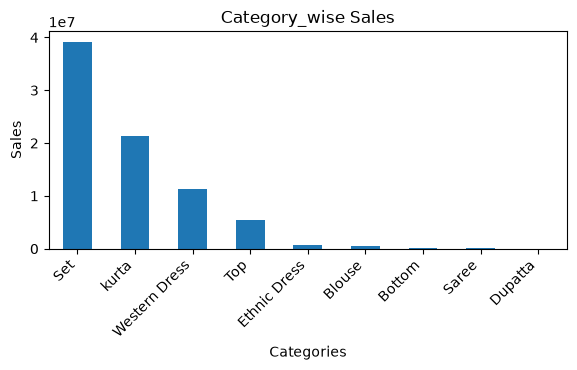

In [110]:
Category_Sales.plot(kind = 'bar', figsize = (6,4))
plt.title('Category_wise Sales')
plt.xlabel('Categories')
plt.ylabel('Sales')
plt.tight_layout()
plt.xticks(rotation = 45 , ha = 'right')
plt.show()

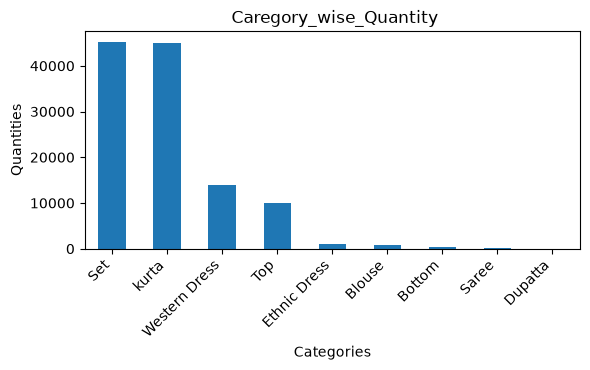

In [111]:
Caregory_wise_Quantity.plot(kind = 'bar', figsize = (6,4))
plt.title(' Caregory_wise_Quantity')
plt.xlabel('Categories')
plt.ylabel('Quantities')
plt.tight_layout()
plt.xticks(rotation = 45 , ha = 'right')
plt.show()

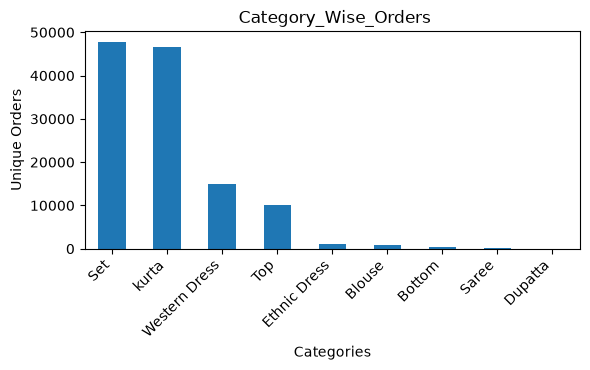

In [112]:
Category_Wise_Orders.plot(kind = 'bar', figsize = (6,4))
plt.title(' Category_Wise_Orders')
plt.xlabel('Categories')
plt.ylabel('Unique Orders')
plt.tight_layout()
plt.xticks(rotation = 45 , ha = 'right')
plt.show()

"“The analysis shows that the Set category recorded the highest sales, followed by Kurta and Western Dress. Set and Kurta categories recorded very similar order volumes and quantities, with Set slightly higher than Kurta. Western Dress ranked third in terms of orders, quantity, and sales, while the remaining categories contributed comparatively lower sales and quantities.”"

# 5.  State - Wise Analysis

In [113]:
State_sales = df.groupby('ship-state')['Amount'].sum().sort_values(ascending = False)

State_wise_Qty = df.groupby('ship-state')['Qty'].sum().sort_values(ascending = False)

State_wise_orders = df.groupby('ship-state')['Order ID'].nunique().sort_values(ascending = False)
print(State_wise_orders)



ship-state
Maharashtra          20780
Karnataka            16182
Tamil Nadu           10519
Telangana            10405
Uttar Pradesh        10062
Delhi                 6533
Kerala                6105
West Bengal           5653
Andhra Pradesh        4979
Gujarat               4169
Haryana               4142
Rajasthan             2512
Madhya Pradesh        2375
Odisha                2024
Bihar                 2017
Punjab                1809
Assam                 1601
Uttarakhand           1480
Jharkhand             1382
Goa                   1081
Chhattisgarh           873
Himachal Pradesh       750
Jammu & Kashmir        670
Chandigarh             315
Puducherry             310
Manipur                287
Andaman & Nicobar      242
Sikkim                 197
Meghalaya              194
Nagaland               170
Tripura                143
Arunachal Pradesh      134
New Delhi               76
Mizoram                 72
Dadra And Nagar         60
Ladakh                  42
Lakshadweep      

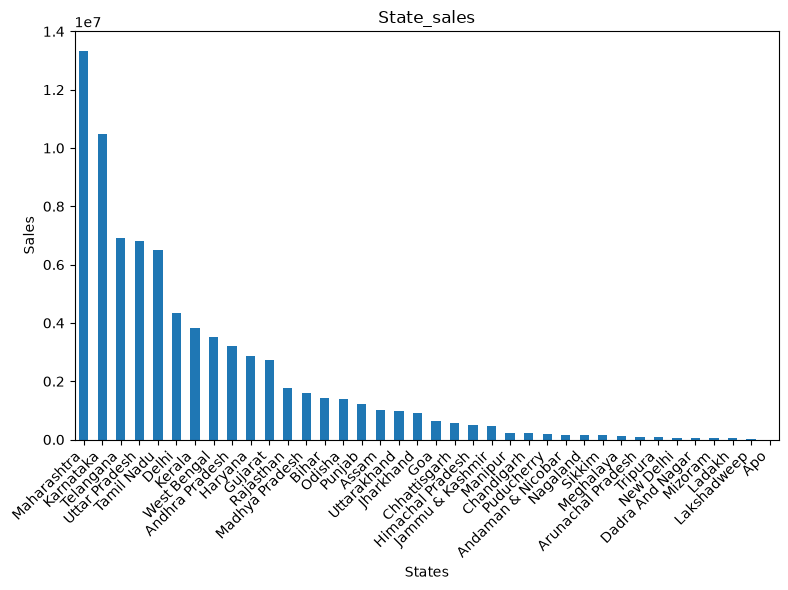

In [114]:
State_sales.plot(kind = 'bar' , figsize = (8,6))
plt.title('State_sales')
plt.xlabel('States')
plt.ylabel('Sales')
plt.xticks(rotation = 45 , ha = 'right')
plt.tight_layout()
plt.show()

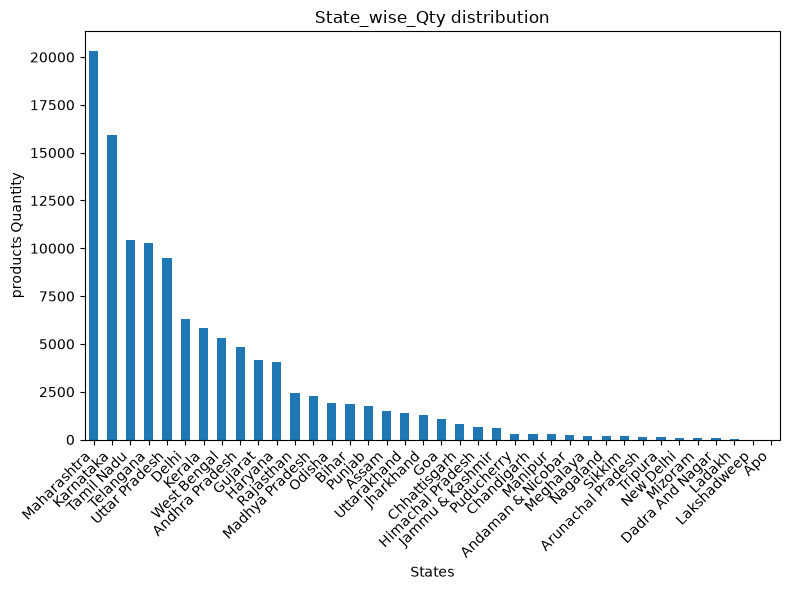

In [115]:
State_wise_Qty.plot(kind = 'bar' , figsize = (8,6))
plt.title('State_wise_Qty distribution')
plt.xlabel('States')
plt.ylabel('products Quantity')
plt.xticks(rotation = 45 , ha = 'right')
plt.tight_layout()
plt.show()

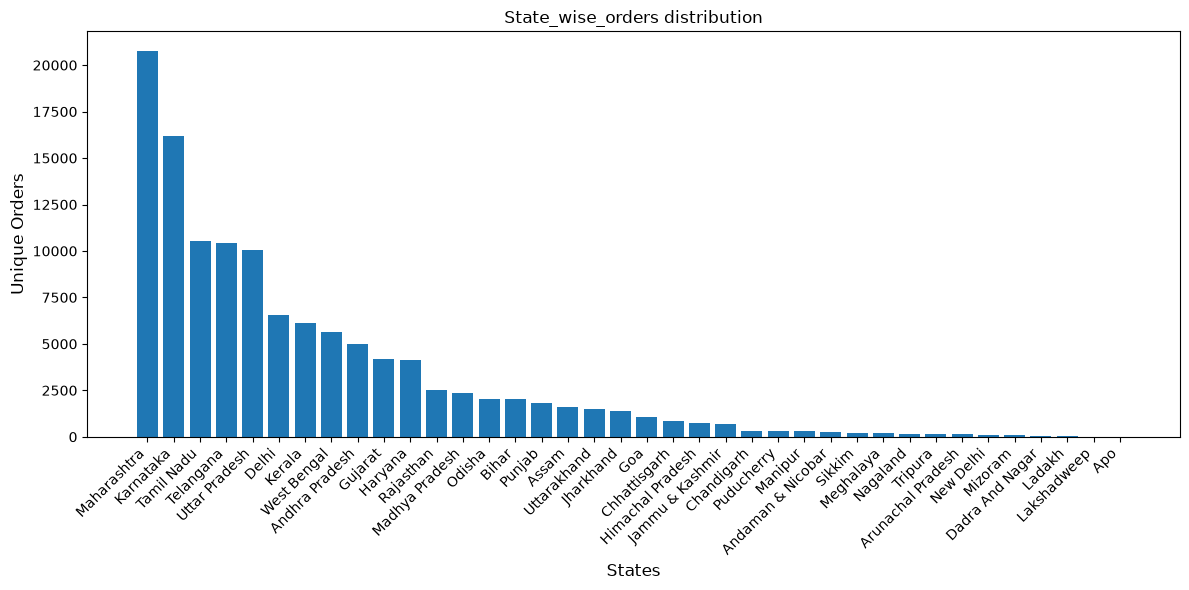

In [116]:
plt.figure(figsize=(12,6))  # figsize should be set here, not inside plt.bar
plt.bar(State_wise_orders.index, State_wise_orders.values)
plt.title('State_wise_orders distribution')
plt.xlabel('States' , fontsize = 12)
plt.ylabel('Unique Orders', fontsize =12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


“Maharashtra recorded the highest sales, order volume, and quantity sold, followed by Karnataka. The remaining states contributed comparatively lower sales, order volume, and quantity sold.”

In [127]:
### Top 5 states in sales 
Top_Sales = State_sales.head(5)
print(Top_Sales)

ship-state
Maharashtra      13335534.14
Karnataka        10481114.37
Telangana         6916615.65
Uttar Pradesh     6816642.08
Tamil Nadu        6515650.11
Name: Amount, dtype: float64


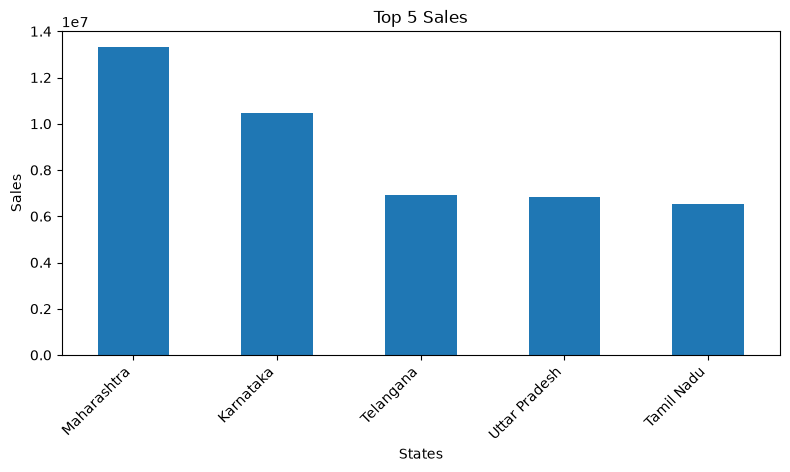

In [128]:
Top_Sales.plot(kind = 'bar' , figsize=(8,5))
plt.title('Top 5 Sales')
plt.xlabel('States')
plt.ylabel('Sales')
plt.tight_layout()
plt.xticks(rotation = 45 , ha = 'right')
plt.show()


 # 6. Fulfilment Analysis

In [129]:
Fulfilment_sales_comparison = df.groupby('Fulfilment')['Amount'].sum().sort_values(ascending = False)
Fulfilment_sales_comparison

Fulfilment
Amazon      54322151.0
Merchant    24270527.3
Name: Amount, dtype: float64

In [130]:
Fulfilment_Order = df.groupby('Fulfilment')['Order ID'].nunique().sort_values(ascending = False)
Fulfilment_Order

Fulfilment
Amazon      84002
Merchant    36376
Name: Order ID, dtype: int64

In [131]:
Fulfilment_Qty = df.groupby('Fulfilment')['Qty'].sum().sort_values(ascending = False)
Fulfilment_Qty

Fulfilment
Amazon      84087
Merchant    32562
Name: Qty, dtype: int64

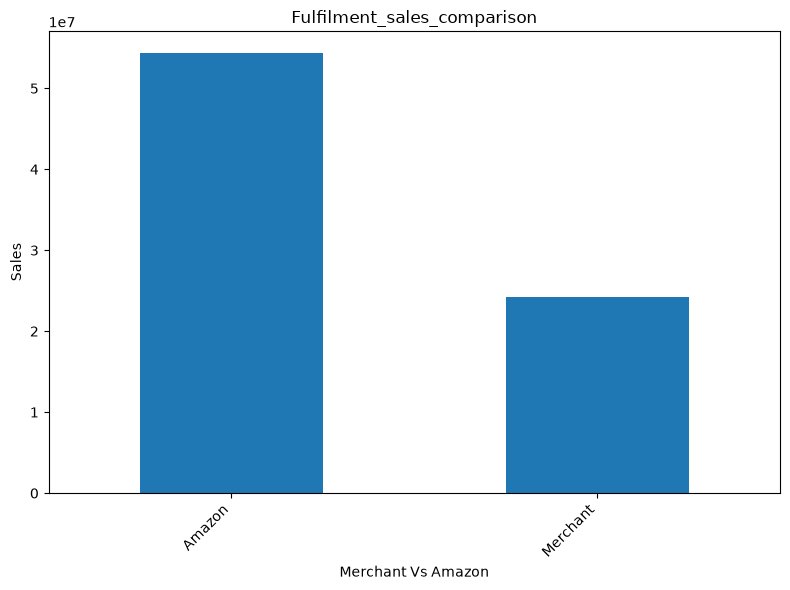

In [132]:
Fulfilment_sales_comparison.plot(kind ='bar', figsize=(8,6))
plt.title('Fulfilment_sales_comparison')
plt.xlabel('Merchant Vs Amazon')
plt.ylabel('Sales')
plt.xticks( rotation = 45 , ha = 'right')
plt.tight_layout()
plt.show()

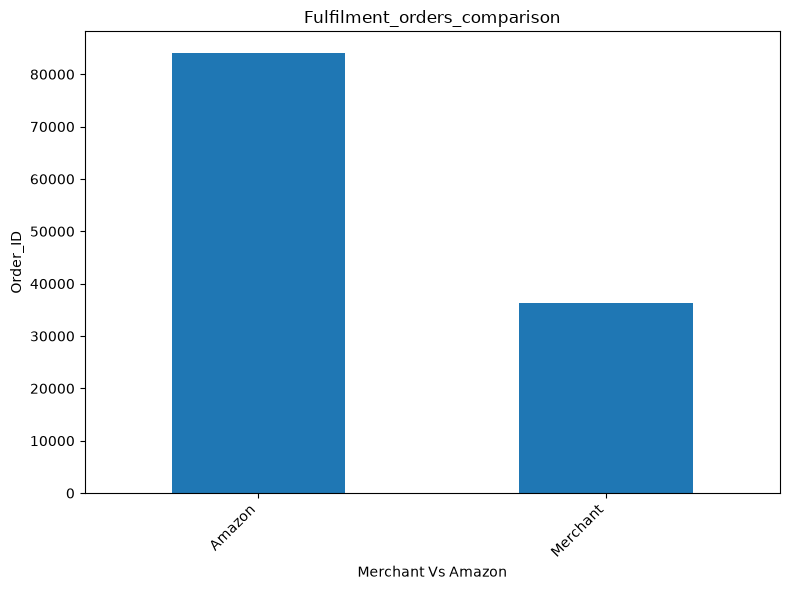

In [133]:
Fulfilment_Order.plot(kind ='bar', figsize=(8,6))
plt.title('Fulfilment_orders_comparison')
plt.xlabel('Merchant Vs Amazon')
plt.ylabel('Order_ID')
plt.xticks( rotation = 45 , ha = 'right')
plt.tight_layout()
plt.show()

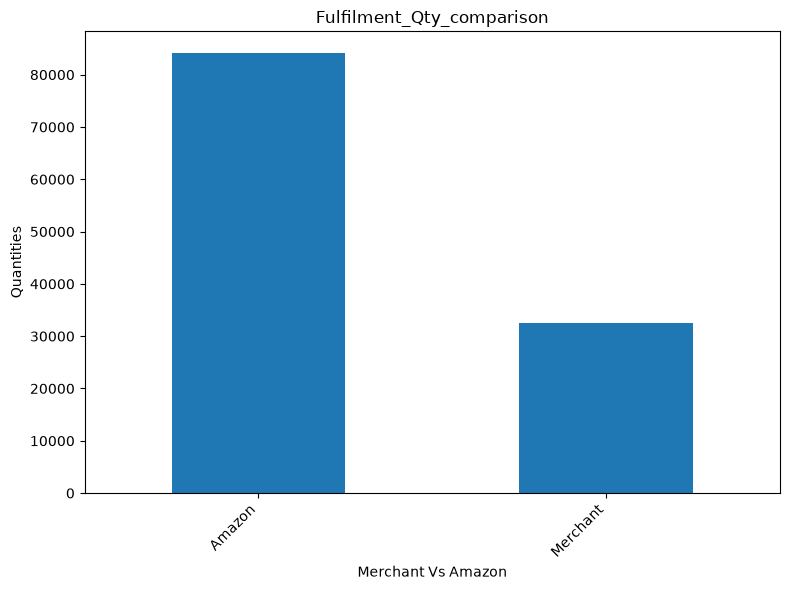

In [134]:
Fulfilment_Qty.plot(kind ='bar', figsize=(8,6))
plt.title('Fulfilment_Qty_comparison')
plt.xlabel('Merchant Vs Amazon')
plt.ylabel('Quantities')
plt.xticks( rotation = 45 , ha = 'right')
plt.tight_layout()
plt.show()

“From the above graphs, fulfilment done by Amazon recorded the highest sales, order quantity, and units compared to merchants — showing Amazon’s dominance in logistics performance.”

#  7. B2B Analysis

In [135]:
B2B_Orders = df.groupby('B2B')['Order ID'].nunique().sort_values(ascending = False)
B2B_Orders 

B2B
False    119584
True        794
Name: Order ID, dtype: int64

In [136]:
B2B_Sales = df.groupby('B2B')['Amount'].sum().sort_values(ascending = False)
B2B_Sales

B2B
False    78001457.51
True       591220.79
Name: Amount, dtype: float64

In [137]:
B2B_Qty = df.groupby('B2B')['Qty'].sum().sort_values(ascending = False)
B2B_Qty

B2B
False    115809
True        840
Name: Qty, dtype: int64

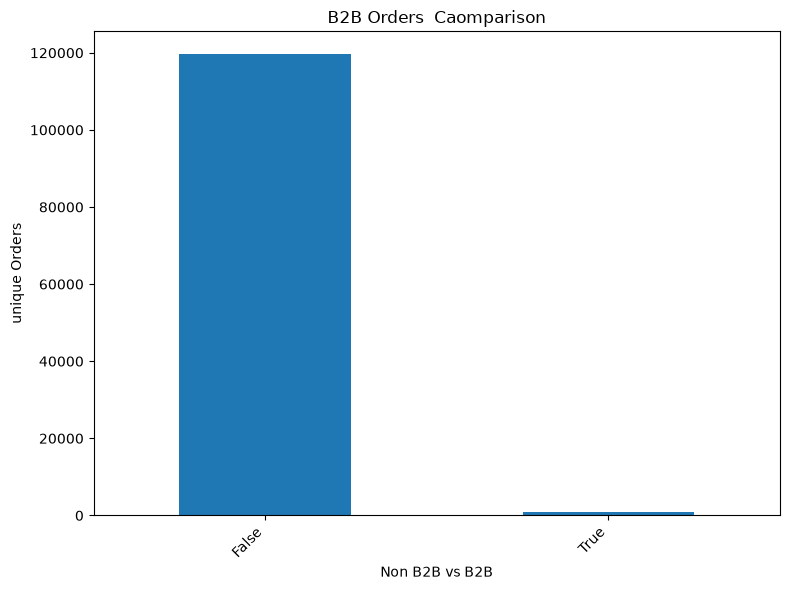

In [138]:
B2B_Orders.plot(kind = 'bar' , figsize = (8,6))
plt.title('B2B Orders  Caomparison')
plt.xlabel('Non B2B vs B2B')
plt.ylabel('unique Orders')
plt.xticks(rotation = 45 , ha = 'right')
plt.tight_layout()
plt.show()

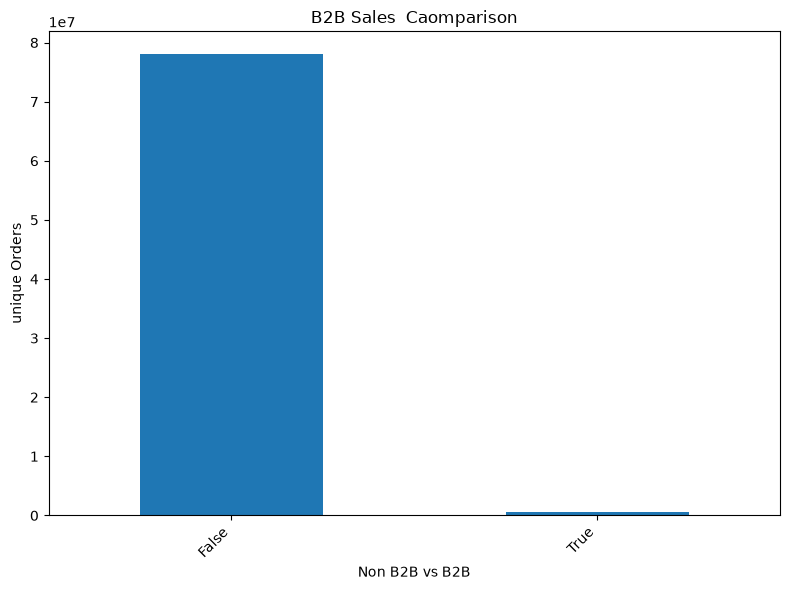

In [139]:
B2B_Sales.plot(kind = 'bar' , figsize = (8,6))
plt.title('B2B Sales  Caomparison')
plt.xlabel('Non B2B vs B2B')
plt.ylabel('unique Orders')
plt.xticks(rotation = 45 , ha = 'right')
plt.tight_layout()
plt.show()

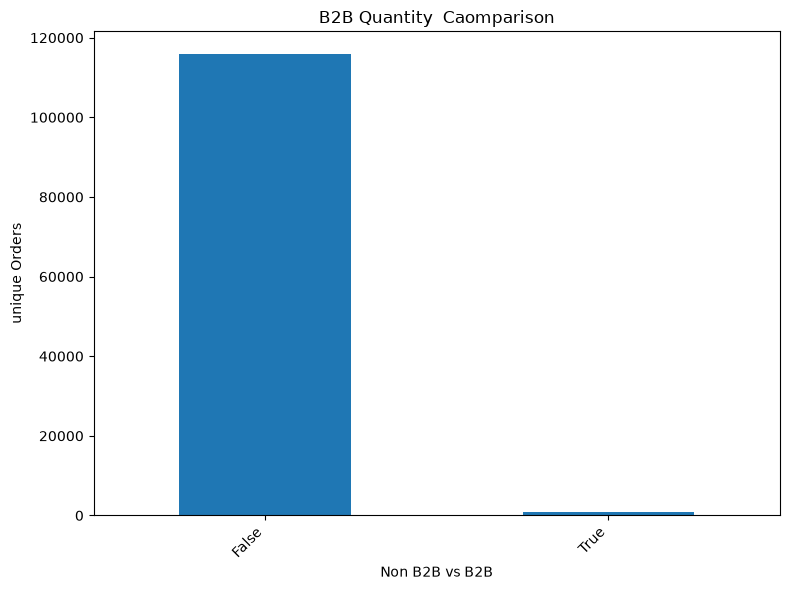

In [140]:
B2B_Qty.plot(kind = 'bar' , figsize = (8,6))
plt.title('B2B Quantity  Caomparison')
plt.xlabel('Non B2B vs B2B')
plt.ylabel('unique Orders')
plt.xticks(rotation = 45 , ha = 'right')
plt.tight_layout()
plt.show()

"From the above graphs Non-B2B recorded  highest order sales , quantity volume  and orders volume compare to B2B"

# 8.  Promotion /Marketing Analysis

In [118]:
promotion_usage =  df['promotion-ids'].notna().value_counts()
print(promotion_usage)

promotion-ids
True     79822
False    49153
Name: count, dtype: int64


In [119]:
promotion_orders = df.groupby(df['promotion-ids'].notna())['Order ID'].nunique().sort_values(ascending = False)
promotion_orders

promotion-ids
True     73464
False    46937
Name: Order ID, dtype: int64

In [120]:
promotion_sales = df.groupby(df['promotion-ids'].notna())['Amount'].sum().sort_values(ascending = False)
promotion_sales

promotion-ids
True     53588435.0
False    25004243.3
Name: Amount, dtype: float64

In [121]:
promotion_Qty = df.groupby(df['promotion-ids'].notna())['Qty'].sum().sort_values(ascending = False)
promotion_Qty

promotion-ids
True     79851
False    36798
Name: Qty, dtype: int64

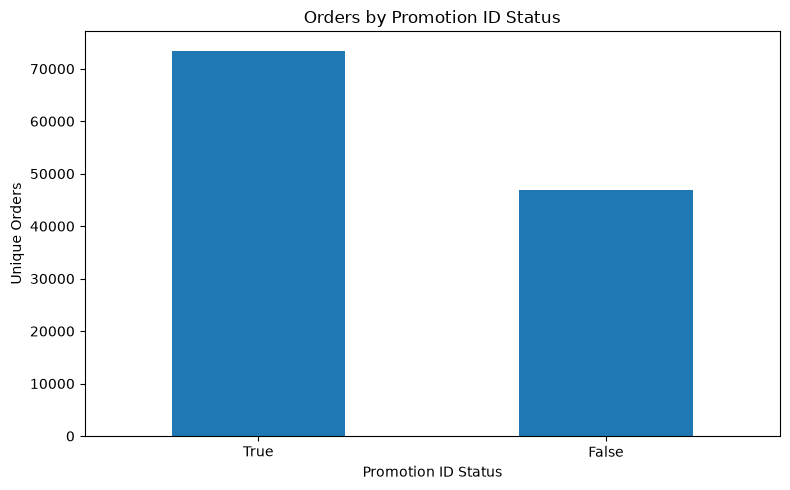

In [122]:
promotion_orders.plot(kind='bar', figsize=(8,5))

plt.title('Orders by Promotion ID Status')
plt.xlabel('Promotion ID Status')
plt.ylabel('Unique Orders')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

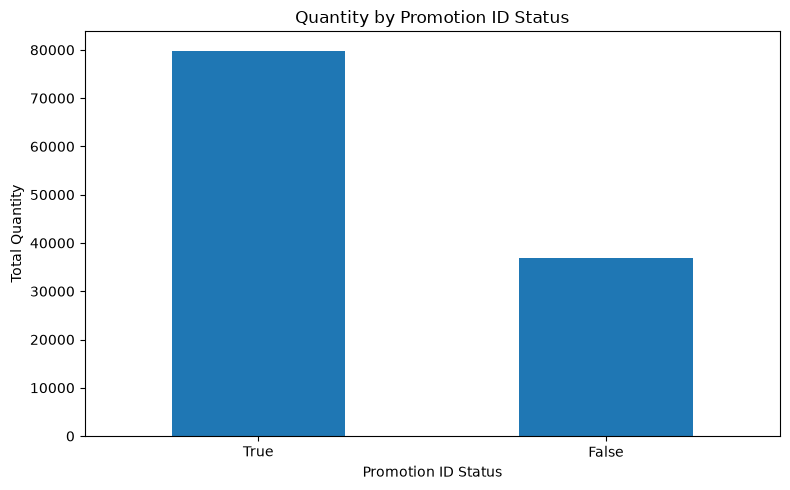

In [123]:
promotion_Qty.plot(kind='bar', figsize=(8,5))

plt.title('Quantity by Promotion ID Status')
plt.xlabel('Promotion ID Status')
plt.ylabel('Total Quantity')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

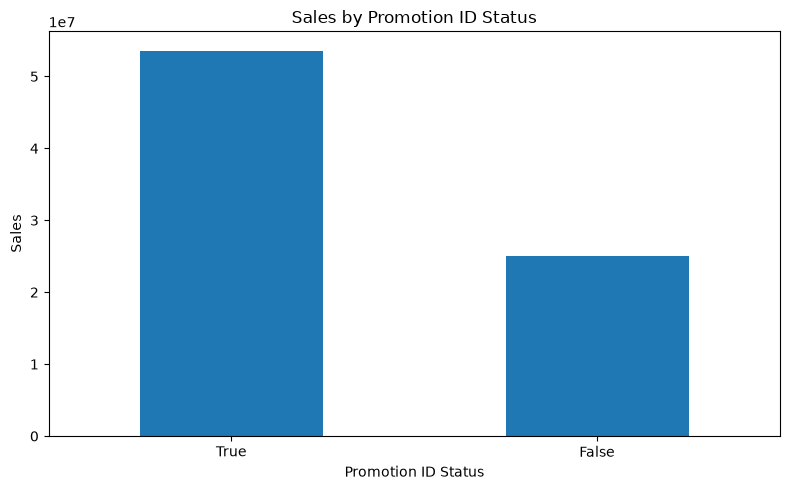

In [124]:
promotion_sales.plot(kind = 'bar' , figsize=(8,5))
plt.title('Sales by Promotion ID Status')
plt.xlabel('Promotion ID Status')
plt.ylabel('Sales')
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()


“The analysis shows that records with a Promotion ID recorded have higher order volume, quantity sold, and sales compared to records where the Promotion ID is missing.”"

# Final Business Insights

## 1.Overall Performance


    

The dataset contains 120,378 unique orders, with total sales of approximately ₹7.85 crore and 116,646 units sold. The average order value is approximately ₹653.

## 2. Order Status

Shipped orders have the highest contribution with 72,826 unique orders, followed by other order statuses. 17,185 unique orders are recorded as cancelled.

## 3.Courier Status

Shipped has the highest contribution among courier statuses, accounting for approximately 84.93%, followed by Unshipped and Cancelled.

## 4. Time Analysis

April has the highest contribution in terms of orders, quantity sold, and sales, with approximately ₹2.88 crore sales and 44,206 units sold. From April to June, orders, quantity and sales decrease.

## 5.Category Analysis

Set contributes the highest sales, followed by Kurta and Western Dress. Set and Kurta have very similar order volumes and quantities.

## 6.  State Analysis

Maharashtra has the highest contribution in sales, order volume, and quantity sold, followed by Karnataka.

## 7. Fulfilment Analysis

Amazon fulfilment contributes more in terms of orders, quantity sold, and sales compared with Merchant fulfilment.

## 8.B2B Analysis

Non-B2B transactions contribute considerably more orders, quantity and sales than B2B transactions.

## 9. Promotion Analysis


Records with a Promotion ID recorded contribute higher orders, quantity sold, and sales than records where the Promotion ID is missing.

# Overall Conclusion

### The analysis shows that the major contribution comes from Shipped orders, April sales activity, the Set category, Maharashtra, Amazon fulfilment, non-B2B transactions, and records with a Promotion ID recorded. These segments contribute a larger share of the overall orders, quantity, or sales compared with their respective categories.